In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/train.csv', header = None)

# Check the number of rows and columns in the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Check for missing or null values
print(df.isnull().sum())

# Look at the first few rows of the data
print(df.head())

Number of rows: 246008
Number of columns: 122
0           0
1           0
2      143829
3      163543
4      124975
        ...  
117         0
118       811
119    122297
120         0
121         0
Length: 122, dtype: int64
      0     1       2       3     4   5     6       7    8    9    ...  112  \
0   69769  -946  0.1613  0.7960  Panl   N  Bus2  0.0742    0    2  ...  1.0   
1  236977   -92     NaN     NaN   NaN   Y  Othr     NaN    0    3  ...  NaN   
2  168821 -1646  0.1124  0.8504  Panl   N  Bus3  0.0387    0    2  ...  2.0   
3   94708 -1651  0.0263     NaN  Blok   N  Bus3     NaN    0    2  ...  4.0   
4   84556  -977     NaN     NaN   NaN   N  Rest     NaN    0    2  ...  NaN   

    113     114  115 116   117  118     119  120  121  
0 -4670  0.9851  0.0   0  Mard  0.0  0.3333    0    0  
1 -1994     NaN  NaN   0  Mard  0.0     NaN    0    0  
2 -2842  0.9891  0.0   0  Sind  0.0  0.3750    0    1  
3 -1345  0.9682  0.0   0  Sind  0.0  0.0417    0    1  
4  -852     NaN  Na

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,69769,-946,0.1613,0.7960,Panl,N,Bus2,0.0742,0,2,...,1.0,-4670,0.9851,0.0,0,Mard,0.0,0.3333,0,0
1,236977,-92,NaN,NaN,NaN,Y,Othr,NaN,0,3,...,NaN,-1994,NaN,NaN,0,Mard,0.0,NaN,0,0
2,168821,-1646,0.1124,0.8504,Panl,N,Bus3,0.0387,0,2,...,2.0,-2842,0.9891,0.0,0,Sind,0.0,0.3750,0,1
3,94708,-1651,0.0263,NaN,Blok,N,Bus3,NaN,0,2,...,4.0,-1345,0.9682,0.0,0,Sind,0.0,0.0417,0,1
4,84556,-977,NaN,NaN,NaN,N,Rest,NaN,0,2,...,NaN,-852,NaN,NaN,0,Sind,0.0,NaN,0,0


In [5]:
binary_label = df.iloc[:, -1]
print(binary_label)

0         0
1         0
2         1
3         1
4         0
         ..
246003    0
246004    0
246005    0
246006    1
246007    0
Name: 121, Length: 246008, dtype: int64


In [6]:
df.dropna(subset=[121], inplace=True)



In [7]:
print(binary_label)

0         0
1         0
2         1
3         1
4         0
         ..
246003    0
246004    0
246005    0
246006    1
246007    0
Name: 121, Length: 246008, dtype: int64



We found out which data is nan
We have decided that it is not appropriate to fill in the label, because it can manipulate the data.


In [8]:
df[121].isnull().sum()

0

In [9]:
print(binary_label.value_counts())

0    226148
1     19860
Name: 121, dtype: int64


In [10]:
column_names = df.columns

print(column_names)

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            112, 113, 114, 115, 116, 117, 118, 119, 120, 121],
           dtype='int64', length=122)


In [11]:
last_column_name = df.columns[-1]

print(last_column_name)

121


<Axes: xlabel='121', ylabel='count'>

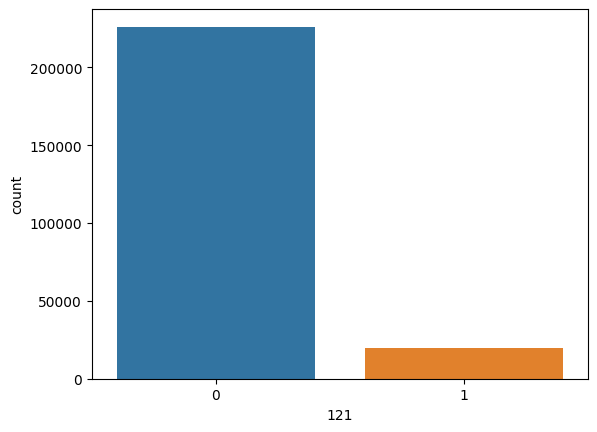

In [12]:
import seaborn as sns
sns.countplot(x=binary_label)

In [13]:
# check for empty data in each row
empty_rows = df[df.isna().any(axis=1)]

# print the empty rows
print(empty_rows)

           0       1       2       3     4   5     6       7    8    9    ...  \
0        69769    -946  0.1613  0.7960  Panl   N  Bus2  0.0742    0    2  ...   
1       236977     -92     NaN     NaN   NaN   Y  Othr     NaN    0    3  ...   
2       168821   -1646  0.1124  0.8504  Panl   N  Bus3  0.0387    0    2  ...   
3        94708   -1651  0.0263     NaN  Blok   N  Bus3     NaN    0    2  ...   
4        84556    -977     NaN     NaN   NaN   N  Rest     NaN    0    2  ...   
...        ...     ...     ...     ...   ...  ..   ...     ...  ...  ...  ...   
246003  248161    -595     NaN     NaN   NaN   N  Bus3     NaN    0    2  ...   
246004  257069   -4334  0.1145  0.8368  Panl   N  Mede  0.1180    0    2  ...   
246005  154350  365243  0.3025  0.6056  Mixd   N  XNAA  0.2233    0    2  ...   
246006  148183  365243     NaN     NaN   NaN   N  XNAA     NaN    0    3  ...   
246007    5167  365243     NaN     NaN   NaN   Y  XNAA     NaN    0    2  ...   

        112   113     114  

In [14]:
mode_value = df[121].mode()[0]
mode_value

0

In [15]:
# Fill the missing values with the mode value
df[121].fillna(mode_value, inplace=True)

In [16]:
df[121].isnull().sum()

0

<Axes: xlabel='121', ylabel='count'>

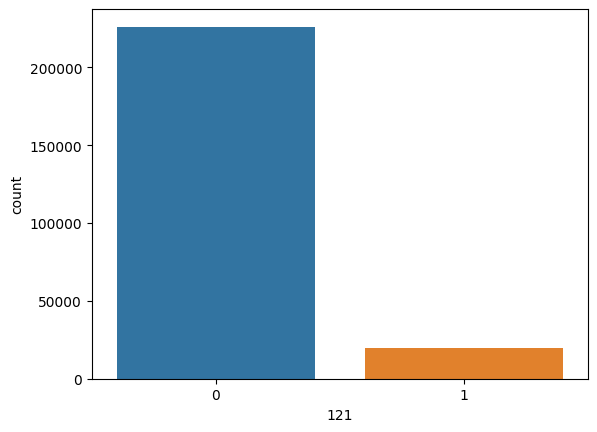

In [17]:
sns.countplot(x=binary_label)

In [18]:
null_count = df[:].isnull().sum()

print(null_count)

0           0
1           0
2      143829
3      163543
4      124975
        ...  
117         0
118       811
119    122297
120         0
121         0
Length: 122, dtype: int64


In [19]:
missing_percentage = null_count / len(df.columns)

In [20]:
# select the columns where the percent of missing values is less than 30%
missing_cols_lower_30 = missing_percentage[missing_percentage < 0.3].index.tolist()
print(missing_cols_lower_30)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [21]:
# select the columns where the percent of missing values is less than 20%
missing_cols_lower_20 = missing_percentage[missing_percentage < 0.2].index.tolist()
print(missing_cols_lower_20)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [22]:
# select the columns where the percent of missing values is less than 10%
missing_cols_lower_10 = missing_percentage[missing_percentage < 0.1].index.tolist()
print(missing_cols_lower_10)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 40, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [23]:
# select the columns where the percent of missing values is less than 5%
missing_cols_lower_5 = missing_percentage[missing_percentage < 0.05].index.tolist()
print(missing_cols_lower_5)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [24]:
# select the columns where the percent of missing values is greater than 30%
missing_cols_upper_30 = missing_percentage[missing_percentage > 0.3].index.tolist()
print(missing_cols_upper_30)

[2, 3, 4, 7, 10, 11, 12, 13, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [25]:
empty_cells_0 = df.iloc[0].isna()

# print the empty cells
print(empty_cells_0)

0      False
1      False
2      False
3      False
4      False
       ...  
117    False
118    False
119    False
120    False
121    False
Name: 0, Length: 122, dtype: bool


In [26]:
empty_count_0 = df[0].isna().sum()

# print the number of empty values
print(empty_count_0)

0


In [27]:
df.iloc[1].isna()



0      False
1      False
2       True
3       True
4       True
       ...  
117    False
118    False
119     True
120    False
121    False
Name: 1, Length: 122, dtype: bool

In [28]:
df[1].isna().sum()



0

In [29]:
df[119].isna().sum()

122297

In [30]:
df[119]

0         0.3333
1            NaN
2         0.3750
3         0.0417
4            NaN
           ...  
246003       NaN
246004    0.3333
246005    0.1667
246006       NaN
246007       NaN
Name: 119, Length: 246008, dtype: float64

In [31]:
empty_cells=df[119].isna().sum()

In [32]:
df[2]

0         0.1613
1            NaN
2         0.1124
3         0.0263
4            NaN
           ...  
246003       NaN
246004    0.1145
246005    0.3025
246006       NaN
246007       NaN
Name: 2, Length: 246008, dtype: float64

In [33]:
df[2].isna().sum()



143829

In [34]:
df.iloc[2].isna()


0      False
1      False
2      False
3      False
4      False
       ...  
117    False
118    False
119    False
120    False
121    False
Name: 2, Length: 122, dtype: bool

In [35]:
# select the columns where the percent of missing values is greater than 30%
missing_cols_upper_30 = missing_percentage[missing_percentage > 0.3].index.tolist()
print(missing_cols_upper_30)

[2, 3, 4, 7, 10, 11, 12, 13, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [36]:
mean_2 = df[2].mean()
df[2].fillna(mean_2, inplace=True)

In [37]:
df[2].isna().sum()


0

In [38]:
mean_3 = df[3].mean()
df[3].fillna(mean_3, inplace=True)

In [39]:
df[3].isna().sum()


0

In [43]:
df[7].isna().sum()

171811

In [44]:
mean_7 = df[7].mean()
df[7].fillna(mean_7, inplace=True)

In [45]:
df[7].isna().sum()

0

In [46]:
for col in missing_cols_upper_30:
    if df[col].dtype == 'float' or df[col].dtype == 'int':
        mean = df[col].mean()
        df[col].fillna(mean, inplace=True)

In [47]:
# Check if any missing values are still present in the columns
missing_values = df[missing_cols_upper_30].isna().values.sum()
if missing_values > 0:
    print(f"There are still {missing_values} missing values in columns {missing_cols_upper_30}")
else:
    print("All missing values have been filled with their mean")


There are still 611068 missing values in columns [2, 3, 4, 7, 10, 11, 12, 13, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [48]:
df[49].isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
246003    False
246004    False
246005    False
246006    False
246007    False
Name: 49, Length: 246008, dtype: bool

In [49]:
df[51].isna().sum()

0

In [50]:
for col in missing_cols_lower_5:
    if df[col].dtype == 'float' or df[col].dtype == 'int':
        mode = df[col].mode()
        df[col].fillna(mode, inplace=True)

In [51]:
# select the columns where the percent of missing values is less than 5%
missing_cols_lower_5 = missing_percentage[missing_percentage < 0.05].index.tolist()
print(missing_cols_lower_5)

[0, 1, 5, 6, 8, 9, 15, 19, 20, 23, 24, 26, 28, 29, 30, 31, 33, 37, 41, 42, 46, 47, 50, 52, 53, 55, 57, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 75, 76, 81, 85, 93, 94, 97, 98, 99, 100, 103, 104, 105, 106, 108, 113, 116, 117, 120, 121]


In [52]:
df[15].isna().sum()

0

In [53]:
# select the columns where the percent of missing values is less than 5%
missing_cols_upper_5 = missing_percentage[missing_percentage > 0.05].index.tolist()
print(missing_cols_upper_5)

[2, 3, 4, 7, 10, 11, 12, 13, 14, 16, 17, 18, 21, 22, 25, 27, 32, 34, 35, 36, 38, 39, 40, 43, 44, 45, 48, 49, 51, 54, 56, 58, 59, 60, 61, 68, 72, 74, 77, 78, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 95, 96, 101, 102, 107, 109, 110, 111, 112, 114, 115, 118, 119]


In [54]:
for col in missing_cols_upper_5:
    if df[col].dtype == 'float' or df[col].dtype == 'int':
        mean = df[col].mean()
        df[col].fillna(mean, inplace=True)

In [55]:
num_missing_per_column = df.isna().sum()

# count the total number of missing values in the dataframe
total_num_missing = num_missing_per_column.sum()

# print the results
print('Number of missing values per column:')
print(num_missing_per_column)
print('Total number of missing values in the dataframe:', total_num_missing)

Number of missing values per column:
0           0
1           0
2           0
3           0
4      124975
        ...  
117         0
118         0
119         0
120         0
121         0
Length: 122, dtype: int64
Total number of missing values in the dataframe: 611071


In [56]:
df[4]

0         Panl
1          NaN
2         Panl
3         Blok
4          NaN
          ... 
246003     NaN
246004    Panl
246005    Mixd
246006     NaN
246007     NaN
Name: 4, Length: 246008, dtype: object

In [57]:
df[4].isna().sum()

124975

In [58]:
df[4].isna().sum()/len(df[4])


0.5080119345712335

In [59]:
object_col=df[4]

In [60]:
print(object_col.value_counts())

Panl    52854
Stok    51862
Blok     7473
Woon     4292
Mixd     1799
Monc     1445
Oths     1308
Name: 4, dtype: int64


<Axes: xlabel='4', ylabel='count'>

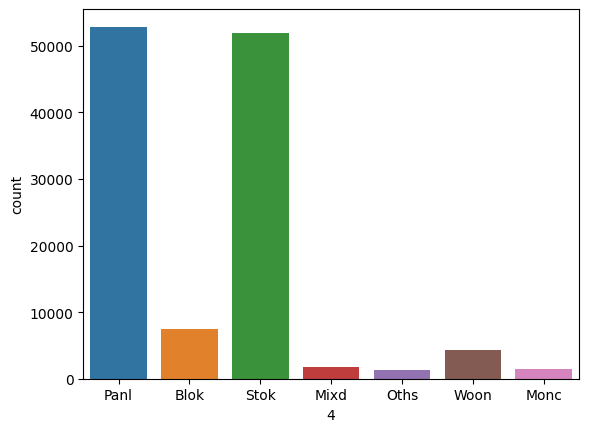

In [61]:
sns.countplot(x=object_col)

In [66]:
# Count the number of empty rows in the column
num_nulls = df[4].isnull().sum()
# Calculate the number of rows to fill with "Panl" and "Stok"
num_panl = num_stok = num_nulls // 2
if num_nulls % 2 != 0:
    # If there is an odd number of empty rows, randomly choose one to fill with either "Panl" or "Stock"
    coin_flip = np.random.randint(2)
    if coin_flip == 0:
        num_panl += 1
    else:
        num_stok += 1

# Fill the empty rows with "Panl" and "Stok"
values = ['Panl'] * num_panl + ['Stok'] * num_stok
np.random.shuffle(values)
df.loc[df[4].isnull(), 4] = values

<Axes: xlabel='4', ylabel='count'>

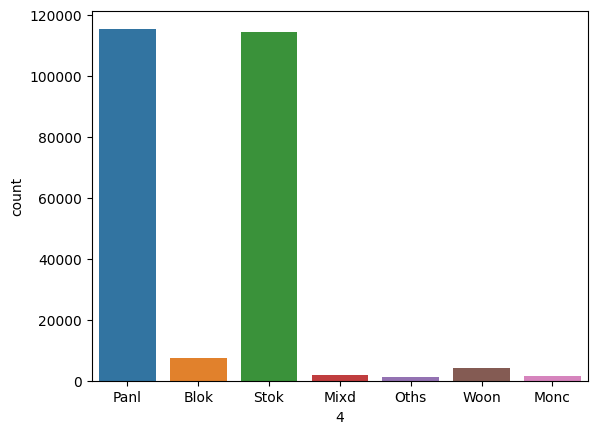

In [67]:
sns.countplot(x=object_col)

In [70]:
df.columns

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            112, 113, 114, 115, 116, 117, 118, 119, 120, 121],
           dtype='int64', length=122)

In [69]:
df.index

RangeIndex(start=0, stop=246008, step=1)

In [68]:
num_missing_per_column = df.isna().sum()

# count the total number of missing values in the dataframe
total_num_missing = num_missing_per_column.sum()

# print the results
print('Number of missing values per column:')
print(num_missing_per_column)
print('Total number of missing values in the dataframe:', total_num_missing)

Number of missing values per column:
0      0
1      0
2      0
3      0
4      0
      ..
117    0
118    0
119    0
120    0
121    0
Length: 122, dtype: int64
Total number of missing values in the dataframe: 486096


In [71]:
f_stat, p_val = f_oneway(df.columns, df.index)

print('F-statistic:', f_stat)
print('p-value:', p_val)

F-statistic: 365.63410629980405
p-value: 1.9144172680352378e-81


this is one-way anova

In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,69769,-946,0.161300,0.796000,Panl,N,Bus2,0.074200,0,2,...,1.0,-4670.0,0.9851,0.00000,0.0,Mard,0.0,0.3333,0.0,0.0
2,168821,-1646,0.112400,0.850400,Panl,N,Bus3,0.038700,0,2,...,2.0,-2842.0,0.9891,0.00000,0.0,Sind,0.0,0.3750,0.0,1.0
3,94708,-1651,0.026300,0.751125,Blok,N,Bus3,0.041902,0,2,...,4.0,-1345.0,0.9682,0.00000,0.0,Sind,0.0,0.0417,0.0,1.0
5,114510,365243,0.106700,0.809600,Panl,N,XNAA,0.052500,0,2,...,2.0,-4138.0,0.9861,0.00000,0.0,Mard,0.0,0.4583,0.0,0.0
6,237407,-2285,0.080600,0.751125,Stok,Y,Tra3,0.041902,1,2,...,0.0,-4328.0,0.9747,0.00330,0.0,Cive,1.0,0.1667,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27984,237150,365243,0.084800,0.755200,Stok,N,XNAA,0.031900,0,2,...,0.0,-4456.0,0.9821,0.00690,0.0,Sind,0.0,0.3333,0.0,0.0
27986,127839,365243,0.058200,0.823200,Panl,N,XNAA,0.000000,0,2,...,0.0,-3578.0,0.9871,0.02760,0.0,Sind,0.0,0.0417,0.0,0.0
27987,210460,365243,0.067200,0.751125,Mixd,N,XNAA,0.041902,0,2,...,2.0,-4377.0,0.9777,0.00000,0.0,Widw,4.0,0.1667,0.0,0.0
27989,63658,-1036,0.087026,0.751125,Woon,N,Kinn,0.041902,0,2,...,5.0,-3221.0,0.9662,0.02713,0.0,Mard,1.0,0.0000,0.0,0.0


In [72]:
missing_mask = df.isnull().any()

# select the columns with missing values
missing_cols = df.columns[missing_mask].tolist()

print(missing_cols)

[14, 16, 44, 85, 99, 107, 110]


In [75]:
col_16=df[16]
col_44=df[44]
col_107=df[107]
col_110=df[110]


In [76]:

print(col_16.value_counts())

Unad    199837
Famy     32080
Spor      9068
Chin      2673
OthB      1432
OthA       697
Groe       221
Name: 16, dtype: int64


In [81]:
df[16].isna().sum()

0

In [78]:
df[16].isna().sum()/len(df[16])


0.0

In [79]:

print(col_16.value_counts())

Unad    199837
Famy     32080
Spor      9068
Chin      2673
OthB      1432
OthA       697
Groe       221
Name: 16, dtype: int64


In [82]:
# Fill the empty rows with "Unad"
df[16].fillna('Unad', inplace=True)

<Axes: xlabel='16', ylabel='count'>

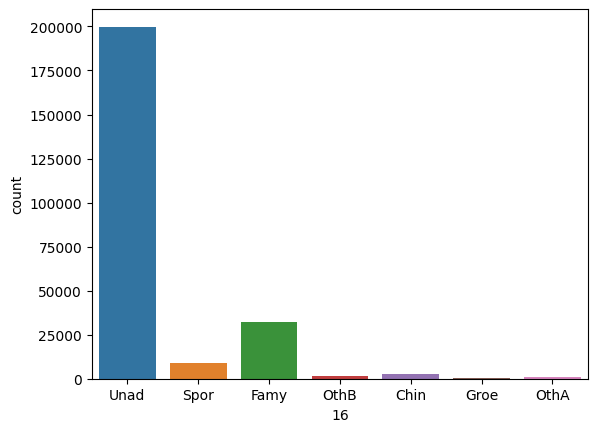

In [83]:
sns.countplot(x=col_16)

In [ ]:
df[44].isna().sum()


4256

In [ ]:

print(col_44.value_counts())

Labs    2428
Salf    1370
Corf    1305
Mans    1081
Dris     781
Higf     638
Accs     498
Medf     378
Secf     243
Clef     226
Coof     214
Prif     133
Secs      67
Lows      64
Waif      51
Reas      39
HR f      37
IT f      33
Name: 44, dtype: int64


In [ ]:
df[44].isna().sum()/len(df[44])


0.3084057971014493

In [ ]:
df[107].isna().sum()


209

In [ ]:

print(col_107.value_counts())

blos    13378
speg      156
tere      119
Name: 107, dtype: int64


In [ ]:
df[107].isna().sum()/len(df[107])


0.015144927536231884

In [ ]:
df[107].isna().sum()


0

In [ ]:
df[110].isna().sum()

4994

In [ ]:

print(col_110.value_counts())

regt    7827
notd     526
orgt     500
Name: 110, dtype: int64


In [ ]:
df[110].isna().sum()/len(df[110])


0.35302773894489

In [ ]:
bla=df[119]

<Axes: xlabel='119', ylabel='count'>

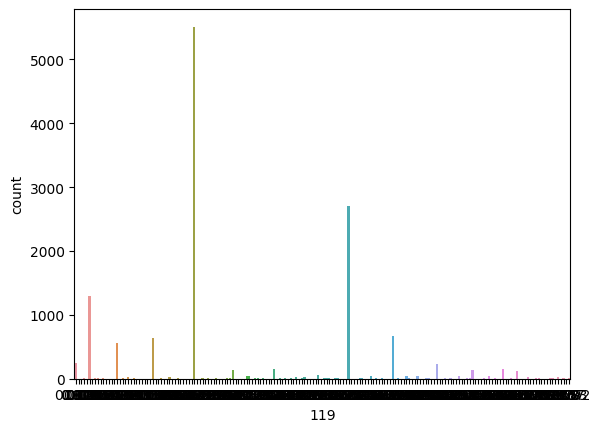

In [ ]:
sns.countplot(x=bla)

DOKUNMUYORUM